# Benchmark 1D 

In [18]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
from generalization import Neural_network, MultiFidelity

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

# Creation of the model

In [19]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

HPO = False

#Benchmark1
highfid = lambda x: (6.*x-2.)**2*np.sin(12.*x-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

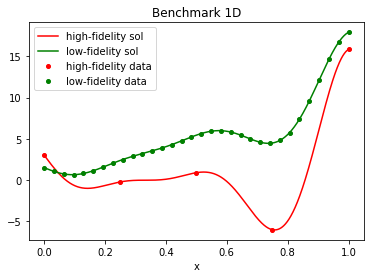

In [20]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [21]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)


## High fidelity model

In [22]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [23]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

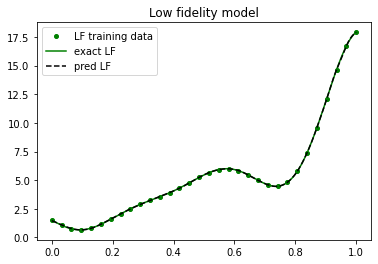

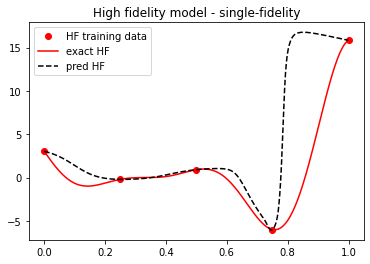

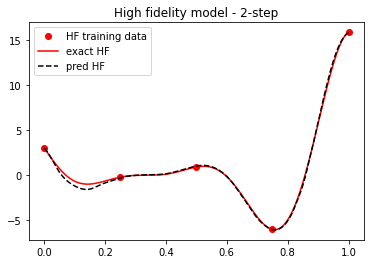

In [24]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [25]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)
# Set parameters for the MCMC
n_samples = np.array([400,800,1200])  # Number of samples
proposal_sds = np.array([3.]) # Standard deviation for the proposal distribution
chain_length=4


In [26]:
# from cuqi.problem import BayesianProblem
# A=Model(forward=modelLF.prediction,range_geometry=Continuous1D(5),domain_geometry=Continuous1D(5))
# x=Uniform(np.zeros(5),np.ones(5))
# y=Gaussian(mean=A(x),cov=proposal_sds[0])
# y_obs=y(x=real_x).sample()
# posterior=JointDistribution(y,x)(y=y_obs)
# BP=BayesianProblem(y,x).set_data(y=y_obs)
# BP.UQ()

In [27]:

class Function:
    def __init__(self, func):
        """
        Initialize the class with a given function.

        Parameters:
        - func: The function for which we want to compute the Jacobian.
        """
        self.func = func

    def compute_jacobian(self, x):
        """
        Compute the Jacobian matrix for the given point x.

        Parameters:
        - x: The point at which to compute the Jacobian.

        Returns:
        - The Jacobian matrix.
        """
        x = np.atleast_1d(x).astype(float)
        n = len(x)
        m = len(self.func(x))

        jacobian = np.zeros((m, n))

        for i in range(n):
            x_copy1 = x.copy()
            x_copy2 = x.copy()

            # Perturb the i-th element
            h = 1e-8
            x_copy1[i] += h
            x_copy2[i] -= h

            # Compute partial derivative using finite difference
            jacobian[:, i] = (self.func(x_copy1) - self.func(x_copy2)) / (2 * h)

        return jacobian

    # def get_jacobian_at_point(self, x):
    #     """
    #     Compute the Jacobian matrix at a specific point.

    #     Parameters:
    #     - x: The point at which to compute the Jacobian.

    #     Returns:
    #     - The Jacobian matrix at the given point.
    #     """
    #     return self.compute_jacobian(x)


# Create an instance of the class
LF_func = Function(modelLF.prediction)
HF_func=Function(modelHF.prediction)
MF_func=Function(final_model.prediction)
# Compute the Jacobian at a specific point
Low_jac = LF_func.compute_jacobian
High_jac = LF_func.compute_jacobian
MF_jac = MF_func.compute_jacobian

# print("Function value at {}: {}".format(point, quadratic_function(point)))
# print("Jacobian at {}: \n{}".format(point, jacobian_at_point))


### Low Fidelity

In [28]:
dim=real_x.shape[0]
mean_prior = np.ones(dim)*0.5
cov_prior = np.diag([0.15, 0.15, 0.15, 0.15,  0.15])
my_prior = multivariate_normal(mean_prior, cov_prior) # modo per settare uniforme?

sigma=0.15
cov_likelihood = sigma**2*np.eye(real_x.shape[0])
my_loglike = tda.GaussianLogLike(highfid(real_x)+np.random.normal(scale=sigma, size=real_x.shape[0]), cov_likelihood)

my_posterior = tda.Posterior(my_prior, my_loglike, modelLF.prediction)

In [29]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = False
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain, α = 0.46:   0%|          | 12/5000 [00:01<06:43, 12.35it/s]C:\Users\Giacomo\AppData\Roaming\Python\Python310\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.00: 100%|██████████| 5000/5000 [06:00<00:00, 13.88it/s]


Sampling chain 2/2


Running chain, α = 0.00: 100%|██████████| 5000/5000 [05:52<00:00, 14.19it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


[-0.4 -0.2  0.   0.2  0.4]


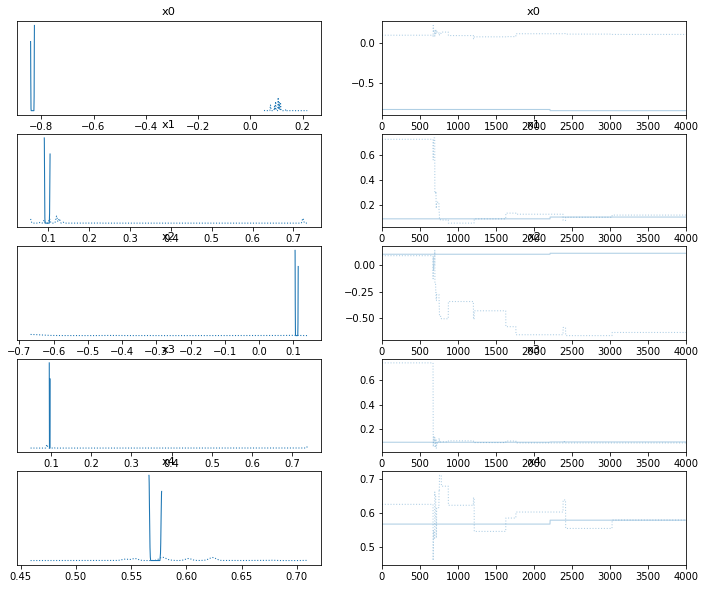

In [30]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
az.summary(idata)
print(real_x-0.5)
az.plot_trace(idata)
plt.show()


In [31]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 0.50:   0%|          | 1/5000 [00:00<09:58,  8.35it/s]C:\Users\Giacomo\AppData\Roaming\Python\Python310\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.16: 100%|██████████| 5000/5000 [06:31<00:00, 12.77it/s]


Sampling chain 2/2


Running chain, α = 0.30: 100%|██████████| 5000/5000 [06:32<00:00, 12.72it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


[-0.4 -0.2  0.   0.2  0.4]


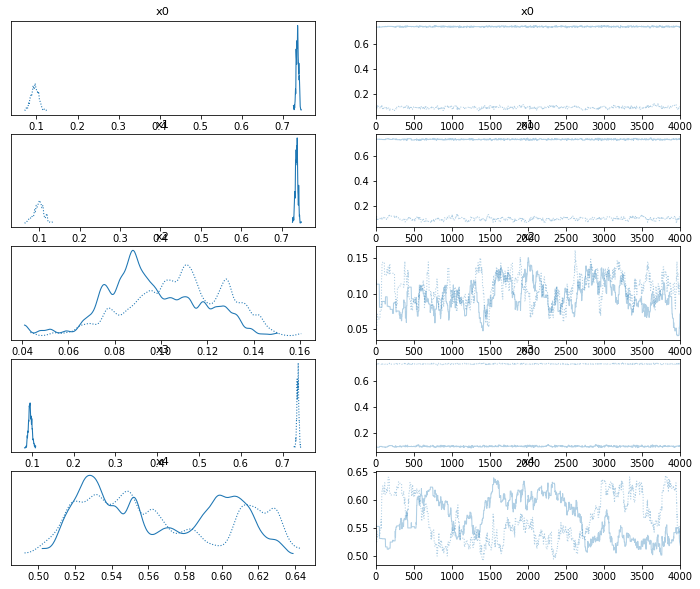

In [32]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
az.summary(idata)
print(real_x-0.5)
az.plot_trace(idata)
plt.show()
